# Test the new paired AV-PedAware dataloader

This notebook loads one sample from the new `data/pairs/<split>/<bag>/<modality>` layout and visualizes each available modality.

In [1]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

from dataloader.avped_pairs_dataloader import AVpedPairsLoader

In [2]:
dataset = AVpedPairsLoader(
    root_path='data/pairs',
    split='train',
    audio_channels=(0, 1, 2, 3),
    include_lidar=True,
    return_metadata=True,
)

spec, image, depth, gt, lidar, meta = dataset[0]
print('samples:', len(dataset))
print('meta:', meta)
print('spec:', tuple(spec.shape))
print('image:', tuple(image.shape))
print('depth:', tuple(depth.shape))
print('gt:', gt.tolist())
print('lidar:', lidar.shape)

samples: 1148
meta: {'split': 'train', 'bag': 'rosbag2_2026_05_17-09_34_07', 'stem': '0001'}
spec: (4, 64, 64)
image: (3, 256, 256)
depth: (1, 256, 256)
gt: [-0.49600446224212646, 1.762170672416687, 0.5677359104156494, 0.7697194218635559, 0.6495212912559509, 1.9728562831878662, -0.0451243594288826]
lidar: (7466, 4)


In [3]:
def bbox_bev_corners(box):
    x, y, _, dx, dy, _, yaw = box
    corners = np.array([
        [dx / 2, dy / 2],
        [dx / 2, -dy / 2],
        [-dx / 2, -dy / 2],
        [-dx / 2, dy / 2],
    ])
    rotation = np.array([
        [np.cos(yaw), -np.sin(yaw)],
        [np.sin(yaw), np.cos(yaw)],
    ])
    return corners @ rotation.T + np.array([x, y])

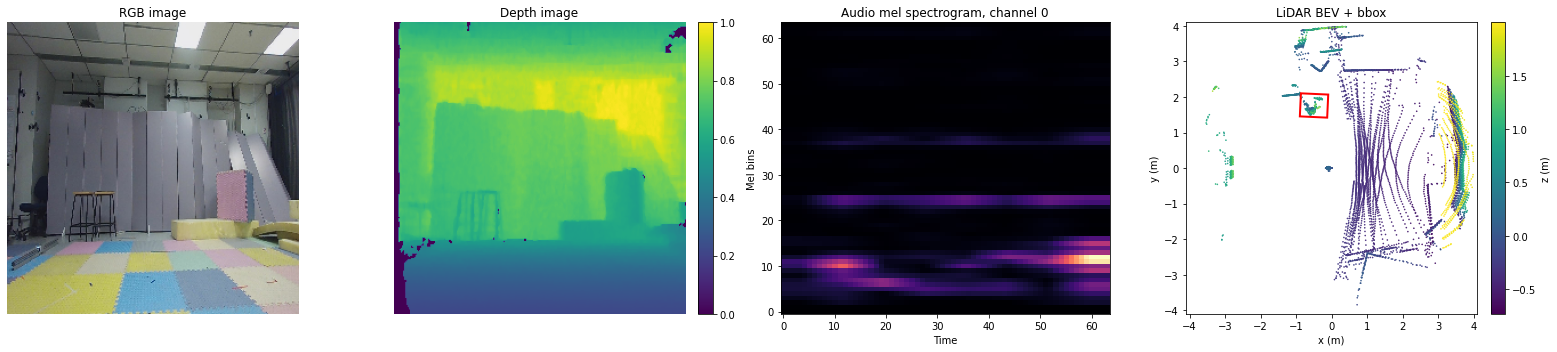

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(image.permute(1, 2, 0).numpy() * 0.5 + 0.5)
axes[0].set_title('RGB image')
axes[0].axis('off')

depth_plot = axes[1].imshow(depth[0].numpy(), cmap='viridis')
axes[1].set_title('Depth image')
axes[1].axis('off')
fig.colorbar(depth_plot, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(spec.numpy()[0], origin='lower', aspect='auto', cmap='magma')
axes[2].set_title('Audio mel spectrogram, channel 0')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Mel bins')

scatter = axes[3].scatter(lidar[:, 0], lidar[:, 1], c=lidar[:, 2], s=0.35, cmap='viridis')
axes[3].add_patch(Polygon(bbox_bev_corners(gt.numpy()), closed=True, fill=False, edgecolor='red', linewidth=2))
axes[3].set_title('LiDAR BEV + bbox')
axes[3].set_xlabel('x (m)')
axes[3].set_ylabel('y (m)')
axes[3].set_xlim(-4.1, 4.1)
axes[3].set_ylim(-4.1, 4.1)
axes[3].set_aspect('equal', adjustable='box')
fig.colorbar(scatter, ax=axes[3], fraction=0.046, pad=0.04, label='z (m)')

fig.tight_layout()
plt.show()